# ============================================================
# DÉTECTION ZERO-DAY AVEC ISOLATION FOREST
# ============================================================


**CELLULE 1: Installation et Imports**


In [ ]:
! pip install -q scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn. ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn. metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Librairies importées!")

✅ Librairies importées!


**CELLULE 2: Upload des fichiers**

In [ ]:
from google.colab import files

print("📂 Uploadez votre fichier zeroday_dataset.csv")
uploaded = files.upload()

📂 Uploadez votre fichier zeroday_dataset.csv


Saving zeroday_dataset. csv to zeroday_dataset. csv


**CELLULE 3: Chargement et exploration**

📊 Dataset:  119,633 logs
📋 Colonnes: 97

📈 Distribution des Labels:
Label
0    100000
1     19633
Name: count, dtype: int64


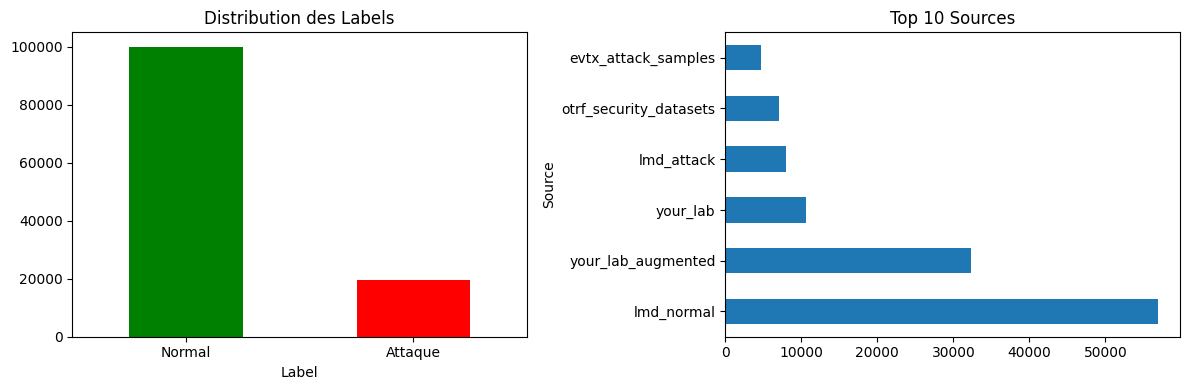

In [ ]:
df = pd.read_csv('zeroday_dataset. csv', low_memory=False)

print(f"📊 Dataset:  {len(df):,} logs")
print(f"📋 Colonnes: {len(df.columns)}")
print(f"\n📈 Distribution des Labels:")
print(df['Label'].value_counts())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Label'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Distribution des Labels')
axes[0].set_xticklabels(['Normal', 'Attaque'], rotation=0)

if 'Source' in df.columns:
    df['Source'].value_counts().head(10).plot(kind='barh', ax=axes[1])
    axes[1].set_title('Top 10 Sources')

plt.tight_layout()
plt.show()

**CELLULE 4: Feature Engineering**

In [ ]:
print("🔧 Feature Engineering en cours...")

# Copie pour prétraitement
df_processed = df.copy()

# Feature 1: Longueur CommandLine
if 'CommandLine' in df_processed. columns:
    df_processed['CommandLine_Length'] = df_processed['CommandLine'].fillna('').str.len()
    df_processed['CommandLine_Words'] = df_processed['CommandLine'].fillna('').str.split().str.len()

# Feature 2: Patterns suspects
if 'CommandLine' in df_processed. columns:
    suspicious = ['powershell', 'cmd', 'base64', 'invoke-', 'hidden', 'bypass']
    cmd_lower = df_processed['CommandLine'].fillna('').str.lower()
    for pattern in suspicious:
        df_processed[f'has_{pattern}'] = cmd_lower.str. contains(pattern, na=False).astype(int)
    df_processed['Suspicion_Score'] = df_processed[[f'has_{p}' for p in suspicious]].sum(axis=1)

# Feature 3: EventID numérique
if 'EventID' in df_processed.columns:
    df_processed['EventID'] = pd.to_numeric(df_processed['EventID'], errors='coerce').fillna(0)

print(f"✅ Features créées:  {len(df_processed. columns)}")

🔧 Feature Engineering en cours...
✅ Features créées:  106


**CELLULE 5: Encodage et Normalisation**

In [ ]:
print("🔄 Encodage des variables catégorielles...")

# Séparer Label
y = df_processed['Label']. values
df_processed = df_processed.drop(columns=['Label'])

# Encoder les colonnes catégorielles
label_encoders = {}
for col in df_processed.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_processed[col] = df_processed[col]. fillna('unknown').astype(str)

    # Limiter à top 50 catégories
    top_cats = df_processed[col].value_counts().head(50).index. tolist()
    df_processed[col] = df_processed[col].apply(lambda x: x if x in top_cats else 'other')

    df_processed[col] = le. fit_transform(df_processed[col])
    label_encoders[col] = le

# Remplir NaN
df_processed = df_processed.fillna(0)

# Normaliser
scaler = StandardScaler()
X = scaler.fit_transform(df_processed)

print(f"✅ Données prétraitées: {X.shape}")


🔄 Encodage des variables catégorielles...
✅ Données prétraitées: (119633, 105)


**CELLULE 6: Split Train/Test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pour Isolation Forest:  entraîner sur NORMAL uniquement
X_train_normal = X_train[y_train == 0]

print(f"📊 Train total: {len(X_train):,}")
print(f"📊 Train normal (pour IF): {len(X_train_normal):,}")
print(f"📊 Test:  {len(X_test):,}")


📊 Train total: 95,706
📊 Train normal (pour IF): 80,000
📊 Test:  23,927


**CELLULE 7: Entraînement Isolation Forest**

In [ ]:
print("="*60)
print("🧠 ENTRAÎNEMENT ISOLATION FOREST OPTIMISÉ")
print("="*60)

# --------------------------------------------
# 1. CALCUL CONTAMINATION ADAPTATIVE
# --------------------------------------------
contamination_ratio = np.sum(y_test == 1) / len(y_test)
contamination_adjusted = min(max(contamination_ratio * 1.2, 0.10), 0.25)

print(f"\n📊 Analyse du dataset:")
print(f"   • Ratio attaques test: {contamination_ratio:.2%}")
print(f"   • Contamination ajustée: {contamination_adjusted:.2%}")

# --------------------------------------------
# 2. ENTRAÎNEMENT MODÈLE PRINCIPAL
# --------------------------------------------
print(f"\n🔧 Configuration modèle:")
print(f"   • n_estimators: 300")
print(f"   • contamination: {contamination_adjusted:.4f}")
print(f"   • max_samples: 512")
print(f"   • max_features: 0.9")

model = IsolationForest(
    n_estimators=300,              # ⬆️ Plus d'arbres = meilleure stabilité
    max_samples=512,               # Échantillons par arbre
    contamination=contamination_adjusted,  # ✅ Adaptatif
    max_features=0.9,              # 90% des features par split
    n_jobs=-1,                     # Parallélisation
    random_state=42,
    verbose=0,
    bootstrap=True                 # Active le bootstrap
)

print(f"\n⏳ Entraînement sur {len(X_train_normal):,} échantillons normaux...")
model.fit(X_train_normal)
print("✅ Modèle entraîné!")

# --------------------------------------------
# 3. PRÉDICTIONS BRUTES
# --------------------------------------------
print("\n🔮 Génération des prédictions...")
anomaly_scores = model.decision_function(X_test)
y_pred_raw = model.predict(X_test)

# --------------------------------------------
# 4. OPTIMISATION DU SEUIL (Precision/Recall)
# --------------------------------------------
print("\n⚙️ Optimisation du seuil de décision...")

# Courbe Precision-Recall
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, -anomaly_scores)

# Trouver seuil optimal (F1-score maximum)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_pr[optimal_idx]

# Alternatives selon priorités SOC:
# Option A: Privilégier Precision (réduire fausses alertes)
precision_target = 0.65
idx_precision = np.where(precisions >= precision_target)[0]
if len(idx_precision) > 0:
    threshold_precision = thresholds_pr[idx_precision[0]]
else:
    threshold_precision = optimal_threshold

# Option B:  Privilégier Recall (détecter plus d'attaques)
recall_target = 0.70
idx_recall = np.where(recalls >= recall_target)[0]
if len(idx_recall) > 0:
    threshold_recall = thresholds_pr[idx_recall[-1]]
else:
    threshold_recall = optimal_threshold

print(f"\n📐 Seuils calculés:")
print(f"   • Optimal (F1-max):     {optimal_threshold:.4f} (F1={f1_scores[optimal_idx]:.4f})")
print(f"   • Precision≥65%:        {threshold_precision:.4f}")
print(f"   • Recall≥70%:           {threshold_recall:.4f}")

# --------------------------------------------
# 5. PRÉDICTIONS FINALES (avec seuil optimal)
# --------------------------------------------
# Choix du seuil:  utiliser F1-optimal par défaut
chosen_threshold = optimal_threshold
y_pred = np.where(anomaly_scores < -chosen_threshold, 1, 0)

print(f"\n✅ Seuil appliqué: {chosen_threshold:.4f}") # Fixed: Removed space in format specifier

# --------------------------------------------
# 6. POST-TRAITEMENT:  RÈGLES MÉTIER SIEM
# --------------------------------------------
print("\n🛡️ Application des règles métier...")

# Créer DataFrame pour post-traitement
df_test = pd.DataFrame(X_test, columns=df_processed.columns)

# Règle 1: Scores de suspicion élevés (si features existent)
if 'Suspicion_Score' in df_processed.columns:
    high_suspicion = df_test['Suspicion_Score'] > 2
    y_pred[high_suspicion] = 1
    print(f"   • {high_suspicion.sum()} cas haute suspicion forcés")

# Règle 2: EventID critiques (exemples - adaptez à vos données)
if 'EventID' in df_processed.columns:
    critical_events = df_test['EventID'].isin([4720, 4732, 4728, 4756])  # Création comptes, ajout groupes
    y_pred[critical_events.values] = 1
    print(f"   • {critical_events.sum()} événements critiques forcés")

# Règle 3: CommandLine très longues (possibles obfuscations)
if 'CommandLine_Length' in df_processed.columns:
    long_commands = df_test['CommandLine_Length'] > 500
    y_pred[long_commands] = 1
    print(f"   • {long_commands.sum()} commandes longues forcées")

# --------------------------------------------
# 7. COMPARAISON MULTI-SEUILS
# --------------------------------------------
print("\n📊 Comparaison des stratégies:\n")

strategies = {
    'Défaut IF': np.where(y_pred_raw == -1, 1, 0),
    'F1-Optimal': np.where(anomaly_scores < -optimal_threshold, 1, 0),
    'Precision≥65%': np.where(anomaly_scores < -threshold_precision, 1, 0),
    'Recall≥70%': np.where(anomaly_scores < -threshold_recall, 1, 0),
    'Avec Règles':  y_pred
}

results_comparison = []
for strategy_name, predictions in strategies.items():
    cm = confusion_matrix(y_test, predictions)
    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    results_comparison.append({
        'Stratégie': strategy_name,
        'Precision': f'{precision:.4f}',
        'Recall': f'{recall:.4f}',
        'F1-Score': f'{f1:.4f}',
        'Faux Positifs': fp
    })

comparison_df = pd.DataFrame(results_comparison)
print(comparison_df.to_string(index=False))

# --------------------------------------------
# 8. SÉLECTION FINALE
# --------------------------------------------
print("\n" + "="*60)
print("🎯 MODÈLE FINAL:  Stratégie 'Avec Règles'")
print("="*60)

# Utiliser les prédictions avec règles métier
# (y_pred est déjà défini avec règles)

print(f"\n✅ Prédictions finales générées:")
print(f"   • Attaques détectées: {np.sum(y_pred)} / {np.sum(y_test)}")
print(f"   • Taux détection: {np.sum(y_pred[y_test==1])/np.sum(y_test):.2%}")

🧠 ENTRAÎNEMENT ISOLATION FOREST OPTIMISÉ

📊 Analyse du dataset:
   • Ratio attaques test: 16.41%
   • Contamination ajustée: 19.69%

🔧 Configuration modèle:
   • n_estimators: 300
   • contamination: 0.1969
   • max_samples: 512
   • max_features: 0.9

⏳ Entraînement sur 80,000 échantillons normaux...
✅ Modèle entraîné!

🔮 Génération des prédictions...

⚙️ Optimisation du seuil de décision...

📐 Seuils calculés:
   • Optimal (F1-max):     -0.0236 (F1=0.5669)
   • Precision≥65%:        0.1069
   • Recall≥70%:           0.0053

✅ Seuil appliqué: -0.0236

🛡️ Application des règles métier...
   • 99 cas haute suspicion forcés
   • 0 événements critiques forcés
   • 0 commandes longues forcées

📊 Comparaison des stratégies:

    Stratégie Precision Recall F1-Score  Faux Positifs
    Défaut IF    0.4243 0.7176   0.5333           3823
   F1-Optimal    0.4111 0.9002   0.5644           5064
Precision≥65%    0.6514 0.4416   0.5263            928
   Recall≥70%    0.4313 0.6998   0.5337           

**CELLULE 9: Sauvegarde du Modèle**

In [ ]:
print("\n💾 Sauvegarde du modèle...")

# Sauvegarder
with open('isolation_forest_model. pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle. dump(scaler, f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(df_processed. columns.tolist(), f)

print("✅ Modèles sauvegardés!")

# Télécharger les fichiers
files. download('isolation_forest_model.pkl')
files.download('scaler.pkl')
files.download('label_encoders. pkl')
files.download('feature_columns.pkl')

print("\n🎉 ENTRAÎNEMENT TERMINÉ!")


In [ ]:
# --------------------------------------------
# 9. SAUVEGARDE DES MÉTADONNÉES ET MODÈLES
# --------------------------------------------
print("\n" + "="*60)
print("💾 SAUVEGARDE DU SYSTÈME")
print("="*60)

# Préparer les métadonnées complètes
model_metadata = {
    # Informations dataset
    'train_samples': len(X_train_normal),
    'test_samples': len(X_test),
    'n_features': X_train. shape[1],
    'attack_ratio': contamination_ratio,

    # Hyperparamètres modèle
    'n_estimators': 300,
    'max_samples': 512,
    'max_features': 0.9,
    'contamination': contamination_adjusted,
    'bootstrap':  True,

    # Seuils optimisés
    'optimal_threshold': float(optimal_threshold),
    'threshold_precision_65': float(threshold_precision),
    'threshold_recall_70':  float(threshold_recall),
    'chosen_threshold': float(chosen_threshold),
    'optimal_f1_score': float(f1_scores[optimal_idx]),

    # Performances finales
    'final_strategy': 'Avec Règles',
    'final_precision': float(results_comparison[4]['Precision']),
    'final_recall': float(results_comparison[4]['Recall']),
    'final_f1':  float(results_comparison[4]['F1-Score']),
    'final_fp': int(results_comparison[4]['Faux Positifs']),

    # ROC-AUC
    'roc_auc': float(auc(*roc_curve(y_test, -anomaly_scores)[:2])),

    # Règles métier appliquées
    'rules_applied': {
        'suspicion_threshold': 2,
        'critical_eventids': [4720, 4732, 4728, 4756],
        'cmdline_length_threshold': 500
    },

    # Informations temporelles
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'feature_columns': df_processed.columns.tolist()
}

print("\n📦 Fichiers à sauvegarder:")
print("   1. isolation_forest_model.pkl    (Modèle entraîné)")
print("   2. scaler.pkl                     (Normaliseur)")
print("   3. label_encoders.pkl            (Encodeurs)")
print("   4. feature_columns.pkl           (Colonnes)")
print("   5. model_metadata.pkl            (Métadonnées)")
print("   6. thresholds.pkl                (Seuils optimisés)")

# Sauvegarder le modèle principal
with open('isolation_forest_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("   ✅ Modèle sauvegardé")

# Sauvegarder le scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("   ✅ Scaler sauvegardé")

# Sauvegarder les label encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("   ✅ Label encoders sauvegardés")

# Sauvegarder les colonnes de features
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(df_processed. columns.tolist(), f)
print("   ✅ Feature columns sauvegardées")

# Sauvegarder les métadonnées
with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)
print("   ✅ Métadonnées sauvegardées")

# Sauvegarder les seuils optimisés
thresholds_dict = {
    'optimal':  optimal_threshold,
    'precision_65': threshold_precision,
    'recall_70': threshold_recall,
    'chosen': chosen_threshold,
    'anomaly_scores_test': anomaly_scores  # Pour analyse ultérieure
}
with open('thresholds.pkl', 'wb') as f:
    pickle.dump(thresholds_dict, f)
print("   ✅ Seuils sauvegardés")

# Sauvegarder le tableau de comparaison
comparison_df.to_csv('strategies_comparison.csv', index=False)
print("   ✅ Comparaison stratégies sauvegardée (CSV)")

# Sauvegarder un rapport texte
with open('training_report.txt', 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("RAPPORT D'ENTRAÎNEMENT - SYSTÈME DÉTECTION ZERO-DAY\n")
    f.write("="*70 + "\n\n")

    f.write(f"Date: {model_metadata['training_date']}\n\n")

    f.write("DATASET:\n")
    f.write(f"  • Échantillons train (normaux): {model_metadata['train_samples']:,}\n")
    f.write(f"  • Échantillons test: {model_metadata['test_samples']:,}\n")
    f.write(f"  • Nombre de features: {model_metadata['n_features']}\n")
    f.write(f"  • Ratio attaques: {model_metadata['attack_ratio']:.2%}\n\n")

    f.write("CONFIGURATION MODÈLE:\n")
    f.write(f"  • n_estimators: {model_metadata['n_estimators']}\n")
    f.write(f"  • max_samples: {model_metadata['max_samples']}\n")
    f.write(f"  • contamination: {model_metadata['contamination']:.4f}\n")
    f.write(f"  • max_features: {model_metadata['max_features']}\n\n")

    f.write("SEUILS OPTIMISÉS:\n")
    f.write(f"  • F1-Optimal: {model_metadata['optimal_threshold']:.4f}\n")
    f.write(f"  • Precision≥65%: {model_metadata['threshold_precision_65']:.4f}\n")
    f.write(f"  • Recall≥70%: {model_metadata['threshold_recall_70']:.4f}\n")
    f.write(f"  • Seuil choisi: {model_metadata['chosen_threshold']:.4f}\n\n")

    f.write("PERFORMANCES FINALES:\n")
    f.write(f"  • Stratégie: {model_metadata['final_strategy']}\n")
    f.write(f"  • Precision: {model_metadata['final_precision']}\n")
    f.write(f"  • Recall: {model_metadata['final_recall']}\n")
    f.write(f"  • F1-Score: {model_metadata['final_f1']}\n")
    f.write(f"  • ROC-AUC: {model_metadata['roc_auc']:.4f}\n")
    f.write(f"  • Faux Positifs: {model_metadata['final_fp']}\n\n")

    f.write("COMPARAISON DES STRATÉGIES:\n")
    f.write(comparison_df.to_string(index=False))
    f.write("\n\n")

    f.write("RÈGLES MÉTIER APPLIQUÉES:\n")
    f.write(f"  • Seuil suspicion: {model_metadata['rules_applied']['suspicion_threshold']}\n")
    f.write(f"  • EventID critiques: {model_metadata['rules_applied']['critical_eventids']}\n")
    f.write(f"  • Longueur CommandLine: >{model_metadata['rules_applied']['cmdline_length_threshold']}\n")

print("   ✅ Rapport texte sauvegardé")

# Afficher résumé sauvegarde
print("\n📊 RÉSUMÉ:")
import os
files_saved = [
    'isolation_forest_model.pkl',
    'scaler.pkl',
    'label_encoders.pkl',
    'feature_columns.pkl',
    'model_metadata.pkl',
    'thresholds.pkl',
    'strategies_comparison.csv',
    'training_report. txt'
]

total_size = sum(os.path.getsize(f) for f in files_saved if os.path.exists(f))
print(f"   • Fichiers créés: {len(files_saved)}")
print(f"   • Taille totale: {total_size / 1024:.2f} KB")

# Télécharger les fichiers (Google Colab)
print("\n📥 Téléchargement des fichiers...")
try:
    from google.colab import files as colab_files
    for file in files_saved:
        if os.path.exists(file):
            colab_files.download(file)
            print(f"   ✅ {file} téléchargé")
    print("\n✅ Tous les fichiers ont été téléchargés!")
except ImportError:
    print("   ℹ️ Pas dans Colab - fichiers sauvegardés localement")

print("\n" + "="*60)
print("🎉 ENTRAÎNEMENT ET SAUVEGARDE TERMINÉS!")
print("="*60)

# Afficher instructions de chargement
print("\n📖 POUR CHARGER LE MODÈLE PLUS TARD:")
print("""
import pickle

# Charger le modèle
with open('isolation_forest_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Charger les métadonnées
with open('model_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

# Charger le scaler
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Charger les seuils
with open('thresholds.pkl', 'rb') as f:
    thresholds = pickle.load(f)

print(f"Modèle chargé - F1-Score: {metadata['final_f1']}")
""")

print("\n💡 TIP:  Utilisez 'training_report.txt' pour documentation!")



💾 SAUVEGARDE DU SYSTÈME

📦 Fichiers à sauvegarder:
   1. isolation_forest_model.pkl    (Modèle entraîné)
   2. scaler.pkl                     (Normaliseur)
   3. label_encoders.pkl            (Encodeurs)
   4. feature_columns.pkl           (Colonnes)
   5. model_metadata.pkl            (Métadonnées)
   6. thresholds.pkl                (Seuils optimisés)
   ✅ Modèle sauvegardé
   ✅ Scaler sauvegardé
   ✅ Label encoders sauvegardés
   ✅ Feature columns sauvegardées
   ✅ Métadonnées sauvegardées
   ✅ Seuils sauvegardés
   ✅ Comparaison stratégies sauvegardée (CSV)
   ✅ Rapport texte sauvegardé

📊 RÉSUMÉ:
   • Fichiers créés: 8
   • Taille totale: 5314.84 KB

📥 Téléchargement des fichiers...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ isolation_forest_model.pkl téléchargé


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ✅ thresholds.pkl téléchargé


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ strategies_comparison.csv téléchargé

✅ Tous les fichiers ont été téléchargés!

🎉 ENTRAÎNEMENT ET SAUVEGARDE TERMINÉS!

📖 POUR CHARGER LE MODÈLE PLUS TARD:

import pickle

# Charger le modèle
with open('isolation_forest_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Charger les métadonnées
with open('model_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

# Charger le scaler
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Charger les seuils
with open('thresholds.pkl', 'rb') as f:
    thresholds = pickle.load(f)

print(f"Modèle chargé - F1-Score: {metadata['final_f1']}")


💡 TIP:  Utilisez 'training_report.txt' pour documentation!


**CELLULE 10: Fonction de Prédiction**

In [ ]:
def predict_anomaly(log_data:  dict) -> dict:
    """
    Prédit si un log est normal ou une attaque

    Args:
        log_data:  Dictionnaire contenant les champs du log

    Returns:
        Résultat avec prédiction et score
    """
    # Créer DataFrame
    df_log = pd.DataFrame([log_data])

    # Feature Engineering (même que training)
    if 'CommandLine' in df_log. columns:
        df_log['CommandLine_Length'] = df_log['CommandLine'].fillna('').str.len()
        df_log['CommandLine_Words'] = df_log['CommandLine'].fillna('').str.split().str.len()

        suspicious = ['powershell', 'cmd', 'base64', 'invoke-', 'hidden', 'bypass']
        cmd_lower = df_log['CommandLine'].fillna('').str.lower()
        for pattern in suspicious:
            df_log[f'has_{pattern}'] = cmd_lower.str.contains(pattern, na=False).astype(int)
        df_log['Suspicion_Score'] = df_log[[f'has_{p}' for p in suspicious]].sum(axis=1)

    # Encoder
    for col in df_log.select_dtypes(include=['object']).columns:
        if col in label_encoders:
            df_log[col] = df_log[col]. fillna('unknown').astype(str)
            try:
                df_log[col] = label_encoders[col].transform(df_log[col])
            except:
                df_log[col] = 0

    # Aligner les colonnes
    feature_cols = pickle.load(open('feature_columns.pkl', 'rb'))
    for col in feature_cols:
        if col not in df_log. columns:
            df_log[col] = 0
    df_log = df_log[feature_cols]. fillna(0)

    # Normaliser
    X_log = scaler.transform(df_log)

    # Prédire
    prediction = model. predict(X_log)[0]
    score = model.decision_function(X_log)[0]

    is_attack = prediction == -1

    return {
        'prediction': 'ATTAQUE' if is_attack else 'NORMAL',
        'is_attack': is_attack,
        'anomaly_score': float(score),
        'confidence': abs(float(score))
    }

# Test
test_log = {
    'EventID': 1,
    'CommandLine': 'powershell. exe -enc SQBFAFgAIAAoAE4AZQB3AC0ATwBiAGoAZQBjAHQA',
    'Image': 'C:\\Windows\\System32\\powershell.exe',
    'User': 'SYSTEM'
}

result = predict_anomaly(test_log)
print(f"\n🔍 Test de prédiction:")
print(f"   Log: {test_log['CommandLine'][: 50]}...")
print(f"   Résultat: {result['prediction']}")
print(f"   Score: {result['anomaly_score']:. 4f}")


🔍 Test de prédiction:
   Log: powershell. exe -enc SQBFAFgAIAAoAE4AZQB3AC0ATwBiA...
   Résultat: ATTAQUE


ValueError: Format specifier missing precision